# Validation of the Interpolation Model

In [17]:
from __future__ import annotations

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import datetime as dt
import os
import random
import shutil

import plots
import xarray as xr

from sweat.api import run_window_time_series


In [20]:
import logging

from sweat.logging import LoggerManager

LoggerManager.set_level(logging.INFO)


In [21]:
if os.environ.get("SWEAT_TEST_DATA_PATH", None) is None:
    msg = "Variable SWEAT_TEST_DATA_PATH must be set"
    raise ValueError(msg)

In [22]:
def clean(ts):
    """
    Clean outputs
    """
    # Remove directory
    shutil.rmtree(ts, ignore_errors=True)
    # Recreate directory
    os.makedirs(ts, exist_ok=True)

In [23]:
def create_et_copy_dir(
    input_dir: str,
    freq: float | None = None,
    cloud_probability: float | None = None,
) -> str:
    """
    Create a directory containing observed evapotranspiration products for interpolation,
    based on a given acquisition frequency and a probability of cloud-contaminated (invalid) dates.

    Parameters
    ----------
    input_dir : str
        Directory where the evapotranspiration and radiation products are stored.
    freq : float, optional
        Acquisition frequency in days.
    cloud_probability : float, optional
        Probability that an observation is invalid.

    Returns
    -------
    str
        Path to the new directory.
    """
    et_original_dir = os.path.join(input_dir, "et")
    et_copy_dir = os.path.join(input_dir, "et_copy")
    shutil.rmtree(et_copy_dir, ignore_errors=True)
    shutil.copytree(et_original_dir, et_copy_dir)
    files = os.listdir(et_copy_dir)
    files.sort()
    if freq is not None:
        files_to_keep = [f for idx, f in enumerate(files) if idx % freq == 0]
        files_to_delete = set(files) - set(files_to_keep)
        for f in files_to_delete:
            os.remove(os.path.join(et_copy_dir, f))
        files = files_to_keep
    if cloud_probability is not None:
        for f in files:
            if random.random() < cloud_probability:  # noqa: S311
                os.remove(os.path.join(et_copy_dir, f))
    return et_copy_dir

We obtained the observed evapotranspiration and daily radiation products using the **prepare_et_single_date** and **prepare_daily_radiation functions** from **ET-DATASET**.

In [24]:
output_path = "out"
os.makedirs(output_path, exist_ok=True)

In [25]:
input_dir = os.path.join(
    os.environ.get("SWEAT_TEST_DATA_PATH"), "data_validation", "senegal"
)
time = xr.date_range("2024-03-01", "2024-03-31")

In [26]:
dir_sd = os.path.join(input_dir, "et")
dir_rad = os.path.join(input_dir, "daily_radiation")
et_copy_dir = create_et_copy_dir(input_dir, freq=3)

### Output Data

  We then generate the simulated evapotranspiration products using the **run_window_time_series** function from **SWEAT**.

In [27]:
dir_ts = os.path.join(output_path, "et_timeseries")
clean(dir_ts)

In [28]:
run_window_time_series(
    period_start=time[0],
    period_end=time[-1],
    et_single_date_dir=et_copy_dir,
    radiation_dir=dir_rad,
    et_time_series_dir=dir_ts,
    window=7,
    shift=1,
)

25-12-04 13:47:10 :: INFO :: Process timeseries between 20240301 and 20240301: OK
25-12-04 13:47:16 :: INFO :: Process timeseries between 20240301 and 20240302: OK
25-12-04 13:47:22 :: INFO :: Process timeseries between 20240301 and 20240303: OK
25-12-04 13:47:31 :: INFO :: Process timeseries between 20240301 and 20240304: OK
25-12-04 13:47:38 :: INFO :: Process timeseries between 20240301 and 20240305: OK
25-12-04 13:47:45 :: INFO :: Process timeseries between 20240301 and 20240306: OK
25-12-04 13:47:54 :: INFO :: Process timeseries between 20240301 and 20240307: OK
25-12-04 13:48:01 :: INFO :: Process timeseries between 20240302 and 20240308: OK
25-12-04 13:48:09 :: INFO :: Process timeseries between 20240303 and 20240309: OK
25-12-04 13:48:18 :: INFO :: Process timeseries between 20240304 and 20240310: OK
25-12-04 13:48:25 :: INFO :: Process timeseries between 20240305 and 20240311: OK
25-12-04 13:48:33 :: INFO :: Process timeseries between 20240306 and 20240312: OK
25-12-04 13:48:4

We run the model for the Coastal Region of Senegal in March 2024, benefiting from ideal meteorological conditions (no rain or clouds). 

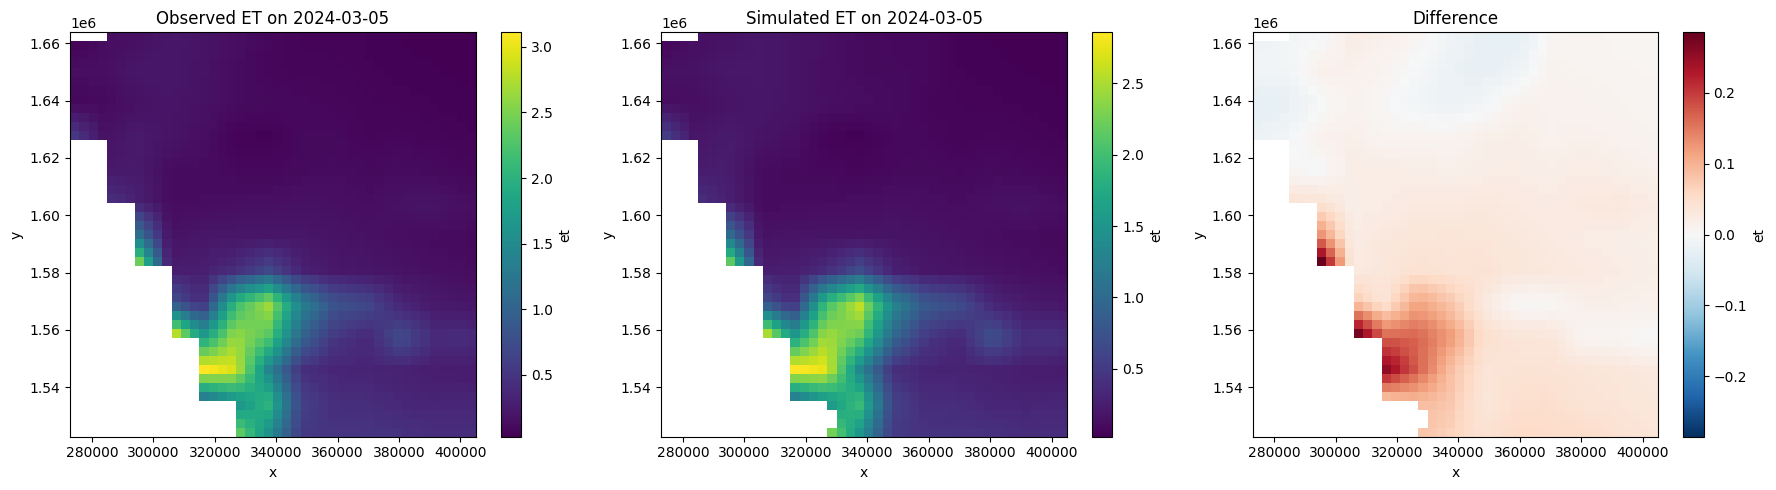

In [29]:
plots.plot_et_comparison(dir_sd, dir_ts, "2024-03-05")

In [30]:
plots.print_daily_statistics("2024-03-05", dir_sd, dir_ts)

######## 2024-03-05 SPATIAL STATISTICS ########
-----ABSOLUTE ERROR-----
        Min                 Argmin    Median              Argmedian       Max  \
0  0.000345  [322479.0, 1634062.0]  0.020966  [379479.0, 1574472.0]  0.284945   

                  Argmax     Mean  
0  [295479.0, 1583881.0]  0.02568  


-----BIAS ERROR-----
        Min                 Argmin    Median              Argmedian       Max  \
0 -0.025605  [274479.0, 1637199.0]  0.020271  [301479.0, 1608972.0]  0.284945   

                  Argmax     Mean  
0  [295479.0, 1583881.0]  0.02568  


-----RMSE-----
value:  0.04281388968229294


-----R²-----
value:  0.9932419136036206


### Spatial Distribution of the Error

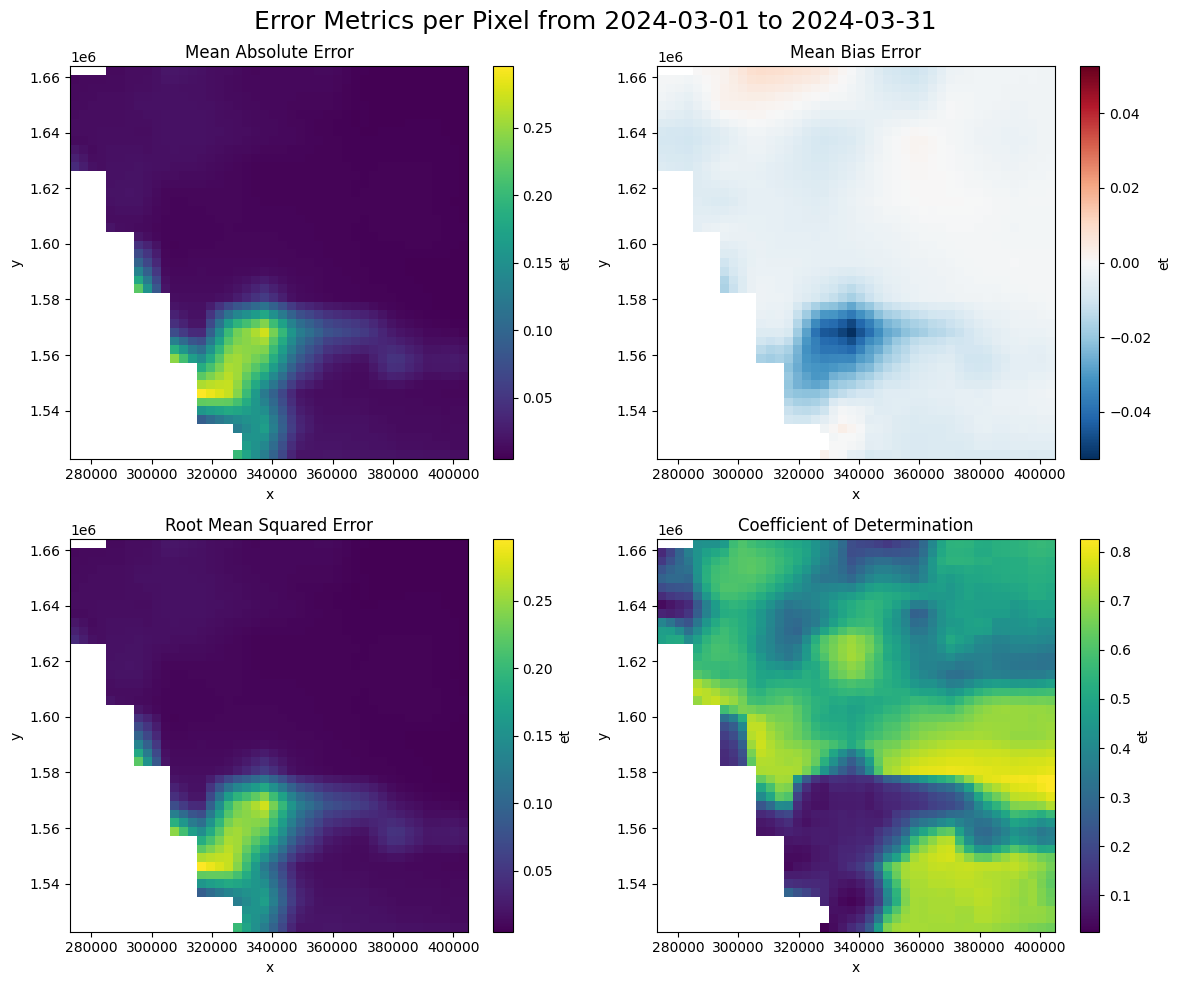

In [ ]:
plots.plot_spatial_distribution_error(
    dir_sd, dir_ts, "2024-03-01", "2024-03-31"
)

In [32]:
plots.print_spatial_statistics(dir_sd, dir_ts, "2024-03-01", "2024-03-31")

######## 2024-03-01-2024-03-31 PERIOD SPATIAL STATISTICS ########
-----MAE-----
        Min             Argmin       Max             Argmax    Median  \
0  0.004716  (403479, 1590153)  0.295369  (316479, 1546244)  0.012292   

           Argmedian  
0  (394479, 1539972)  


-----MBE-----
        Min             Argmin       Max             Argmax    Median  \
0 -0.052581  (337479, 1568199)  0.009184  (307479, 1662290) -0.004231   

           Argmedian  
0  (313479, 1637199)  


-----RMSE-----
        Min             Argmin       Max             Argmax    Median  \
0  0.007085  (403479, 1590153)  0.424358  (316479, 1546244)  0.020738   

           Argmedian  
0  (322479, 1621517)  


-----R²-----
        Min             Argmin       Max             Argmax   Median  \
0  0.025609  (328479, 1524290)  0.825378  (403479, 1577608)  0.50606   

           Argmedian  
0  (334479, 1599562)  


In [ ]:
plots.plot_pixel_error_distribution(
    dir_sd, dir_ts, "2024-03-01", "2024-03-31", "MAE"
)

### Time Evolution of the Error

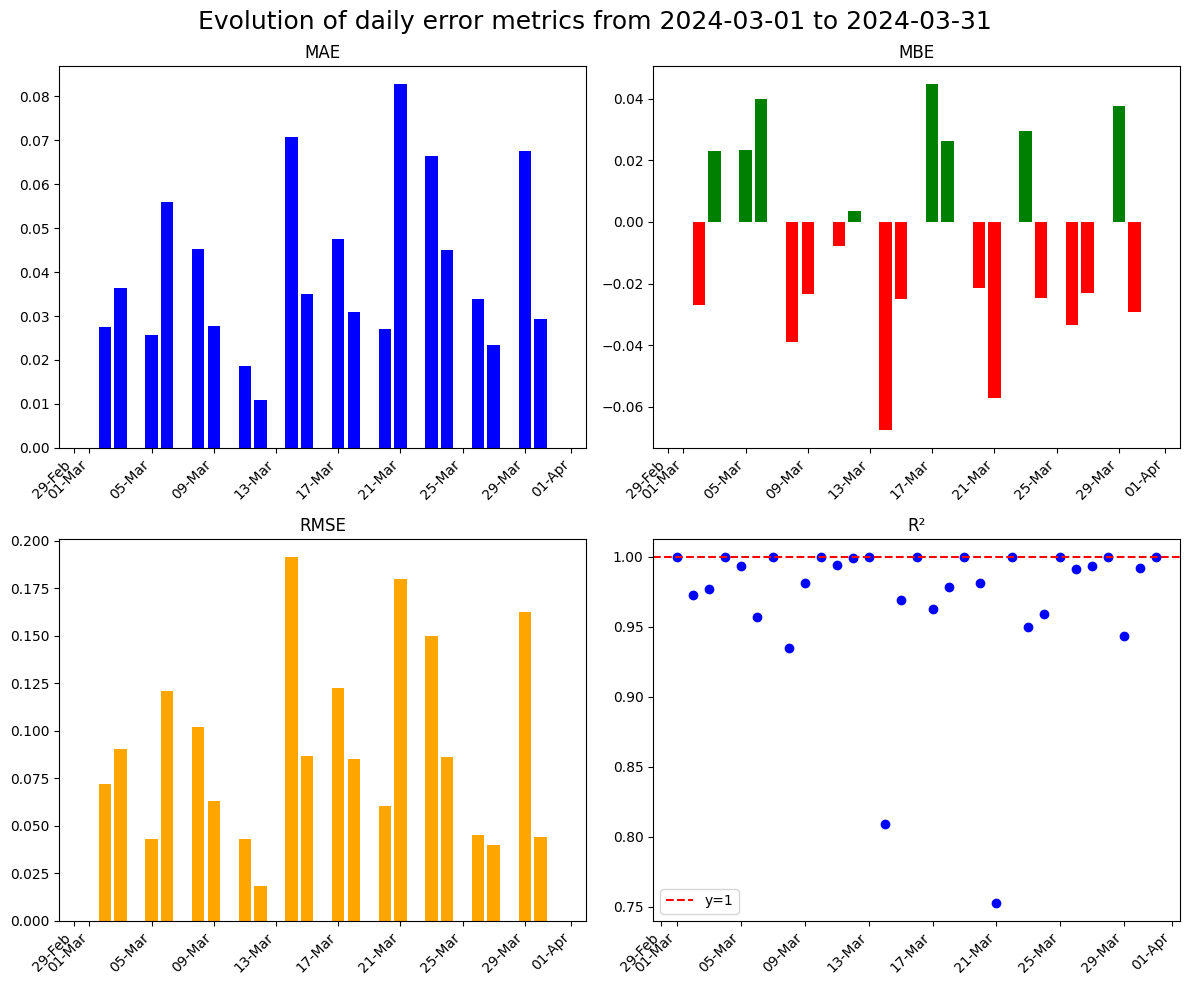

In [33]:
plots.plot_time_evolution_error(dir_sd, dir_ts, "2024-03-01", "2024-03-31")

In [34]:
plots.print_time_statistics(dir_sd, dir_ts, "2024-03-01", "2024-03-31")

######## 2024-03-01-2024-03-31 PERIOD TIME STATISTICS ########
-----MAE-----
   Min (except 0) Argmin (except acquisition day)       Max      Argmax
0        0.010924                      2024-03-12  0.082712  2024-03-21


-----MBE-----


-----RMSE-----
   Min (except 0) Argmin (except acquisition day)       Max      Argmax
0        0.018545                      2024-03-12  0.191182  2024-03-14


-----R²-----
        Min      Argmin  Max (except 1) Argmax (except acquisition day)
0  0.752284  2024-03-21        0.999062                      2024-03-12


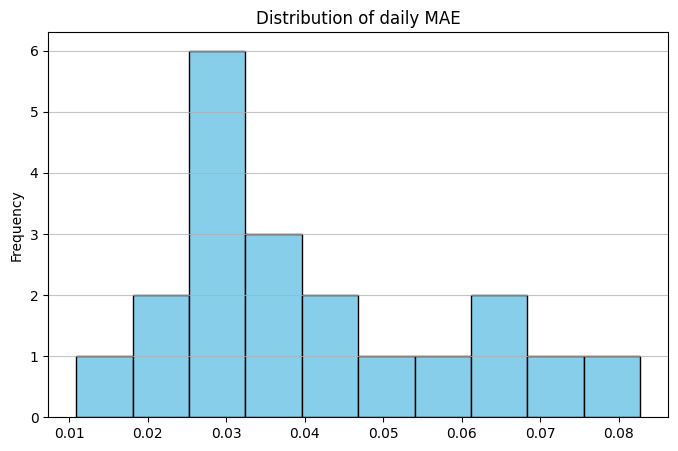

In [35]:
plots.plot_daily_error_distribution(
    dir_sd, dir_ts, "2024-03-01", "2024-03-31", "MAE"
)

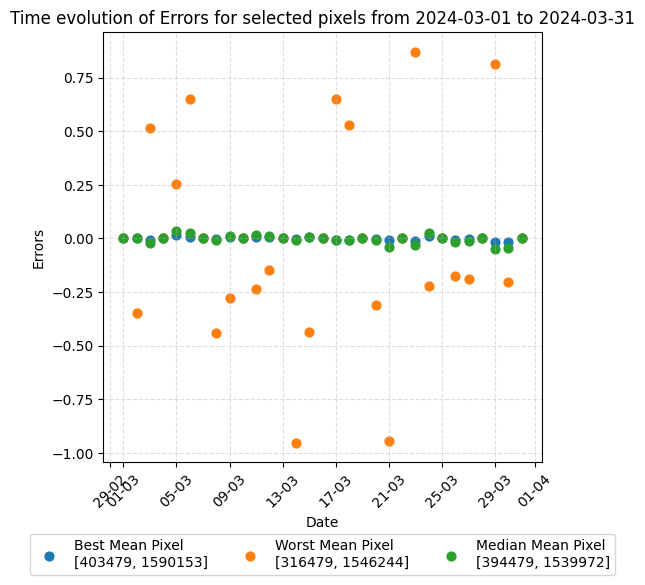

In [36]:
plots.plot_time_evolution_pixel(
    dir_sd, dir_ts, "2024-03-01", "2024-03-31", abs=False
)